2025-09-24 18:17:38,265 - INFO - Using device: cuda
/tmp/ipykernel_3416540/424623633.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_noisy[outlier_indices] += torch.randn(num_outliers) * 5.0 + np.sign(np.random.randn(num_outliers)) * 8
2025-09-24 18:17:38,285 - INFO - Sampled initial lengthscale (Optim mode: MAP): [0.34541602]
2025-09-24 18:17:38,286 - INFO - Using provided initial outputscale (Optim mode: FIX): 1.0
2025-09-24 18:17:38,287 - INFO - Sampled initial dof_func (Optim mode: MAP): 2.6742190567929973
2025-09-24 18:17:38,288 - INFO - Sampled initial dof_lik (Optim mode: MAP): 6.513062145485036
2025-09-24 18:17:38,289 - INFO - Sampled initial noisescale (Optim mode: MAP): 0.015073515412143261
2025-09-24 18:17:38,290 - INFO - Initializing inducing points with Sobol sequence.
2025-09-24 18:17:38,292 - INFO - Starting model training...
2025-09-24 18:17:38,293 - INFO - Starting SVI op

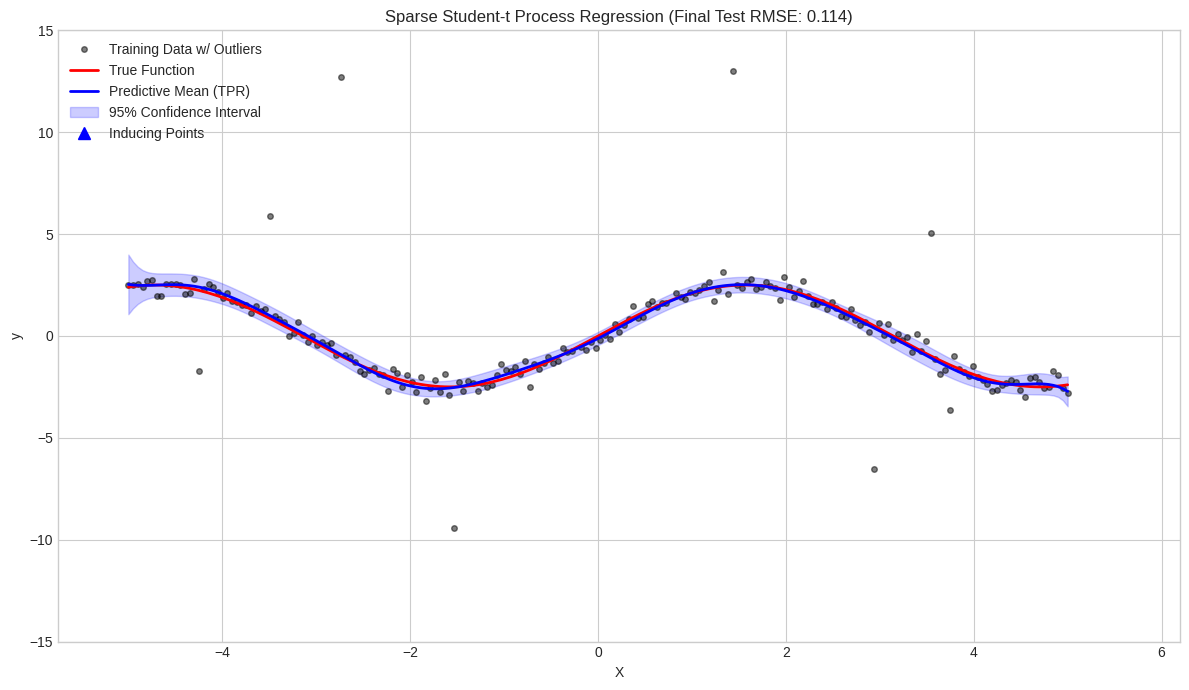

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
import logging

# Assuming the class code is in a file named student.py
from student import SparseTPR

# --- 1. Basic Setup ---
# Set up logging to see the model's training progress
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for CUDA availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
logging.info(f"Using device: {device}")

# --- 2. Generate Synthetic Data ---
# This function creates a sine wave with noise and some large outliers.
def generate_data(num_points, noise_std, num_outliers):
    """Generates synthetic data with outliers."""
    X = torch.linspace(-5, 5, num_points)
    # True underlying function (sine wave)
    y_true = torch.sin(X) * 2.5
    # Add standard Gaussian noise
    y_noisy = y_true + torch.randn(num_points) * noise_std
    
    # Add some significant outliers
    outlier_indices = np.random.choice(num_points, num_outliers, replace=False)
    y_noisy[outlier_indices] += torch.randn(num_outliers) * 5.0 + np.sign(np.random.randn(num_outliers)) * 8
    
    return X.unsqueeze(1), y_noisy.unsqueeze(1), y_true.unsqueeze(1)

# Data parameters
N_train = 200
N_test = 200
noise_std = 0.3
num_outliers = 10

# Create training and test datasets
X_train, y_train, _ = generate_data(N_train, noise_std, num_outliers)
X_test, _, y_test_true = generate_data(N_test, 0.0, 0) # Test data is clean

# Move data to the selected device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test_true = X_test.to(device), y_test_true.to(device)


# --- 3. Initialize and Train the Model ---
# Model parameters
M = 20  # Number of inducing points (much smaller than N_train)
epochs = 150
batch_size = 64
learning_rate = 0.01

# Instantiate the model
# Using 'sobol' initialization for the inducing points

hyper_settings = {
    "lengthscale": {"optim": "MAP"},
    "outputscale": {"optim": "FIX", "init": 1.0},
    "noisescale":  {"optim": "MAP"},
    "dof_func":    {"optim": "MAP"},
    "dof_lik":     {"optim": "MAP"}
}

model = SparseTPR(
    X_train, y_train, M=M, kernel="rbf", 
    inducing_init_method="sobol",
    hyper_settings=hyper_settings, 
    device=device,
)

# The `fit` method is a generator, so we loop through it to train
# and can optionally store the history.
training_history = []
logging.info("Starting model training...")
training_generator = model.fit(
    epochs=epochs,
    batch_size=batch_size,
    hyper_lr=learning_rate,
    X_test=X_test,
    y_test=y_test_true,
    eval_interval=10 # Evaluate on test set every 10 epochs
)

for epoch_result in training_generator:
    training_history.append(epoch_result)
    
final_rmse = training_history[-1]['rmse']
logging.info(f"Training finished. Final Test RMSE: {final_rmse:.4f}")

# --- 4. Make Predictions ---
model.eval() # Set the model to evaluation mode
with torch.no_grad():
    predictive_dist = model.predict(X_test)
    
# Extract predictive mean, standard deviation, and degrees of freedom
pred_mean = predictive_dist['loc'].cpu().numpy()
pred_scale_sq = predictive_dist['scale_sq'].cpu().numpy()
pred_dof = predictive_dist['dof'].cpu().numpy().mean() # Use mean DoF for plotting CI
pred_std = np.sqrt(pred_scale_sq)

# --- 5. Visualize the Results ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the training data (including outliers)
ax.plot(X_train.cpu(), y_train.cpu(), 'ko', markersize=4, alpha=0.5, label='Training Data w/ Outliers')

# Plot the true underlying function
ax.plot(X_test.cpu(), y_test_true.cpu(), 'r-', linewidth=2, label='True Function')

# Plot the model's predictive mean
ax.plot(X_test.cpu(), pred_mean, 'b-', linewidth=2, label='Predictive Mean (TPR)')

# Calculate and plot the 95% confidence interval
# Using the Student-t distribution's percent point function (ppf)
alpha = 0.05 # for 95% CI
t_value = student_t.ppf(1 - alpha / 2, df=pred_dof)
lower_ci = pred_mean - t_value * pred_std
upper_ci = pred_mean + t_value * pred_std
ax.fill_between(X_test.cpu().squeeze(), lower_ci, upper_ci, color='blue', alpha=0.2, label='95% Confidence Interval')

# Plot the optimized inducing point locations
inducing_points = model.Z.detach().cpu().numpy()
ax.plot(inducing_points, np.full_like(inducing_points, ax.get_ylim()[0]), 'b^', markersize=8, label='Inducing Points')

# Final plot settings
ax.set_title(f'Sparse Student-t Process Regression (Final Test RMSE: {final_rmse:.3f})')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.legend(loc='upper left')
ax.set_ylim(-15, 15) # Adjust y-limits to see outliers clearly
plt.tight_layout()
plt.savefig('sparse_tpr_regression.png', dpi=300)